Loaded: Image_1 .jpeg (4032, 3024, 3)
Loaded: Image_2 .jpeg (4032, 3024, 3)
Loaded: Image_3.jpeg (4032, 3024, 3)


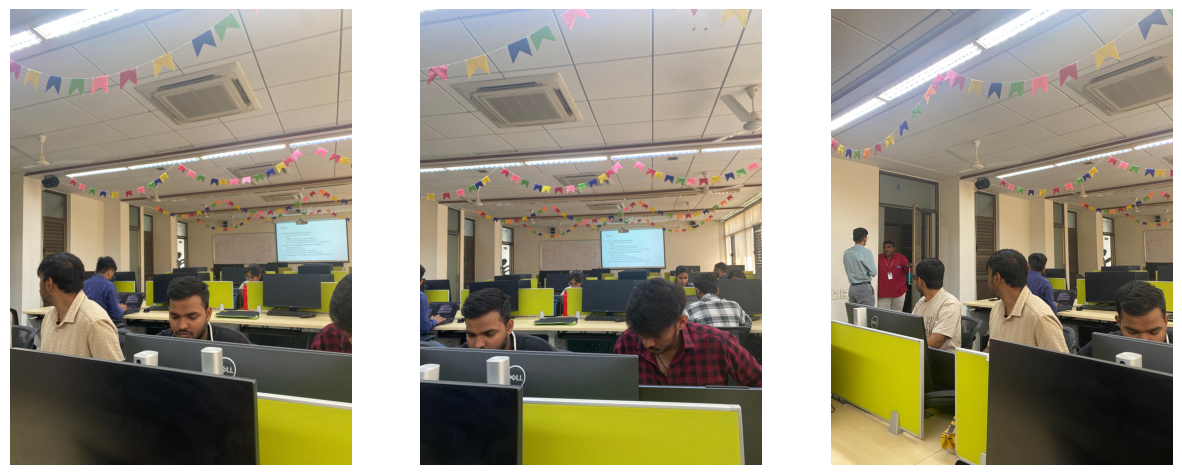


Manual Stitching


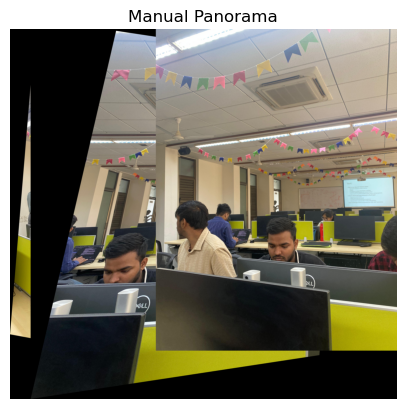


OpenCV Stitcher


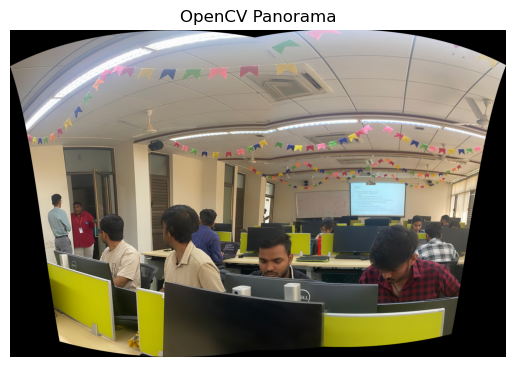


Deep Stitching

🔹 Processing image 1...
✅ Deep similarity: 0.8948512
Matches found: 342
✅ Stitching success

🔹 Processing image 2...
✅ Deep similarity: 0.8042907
Matches found: 67
✅ Stitching success


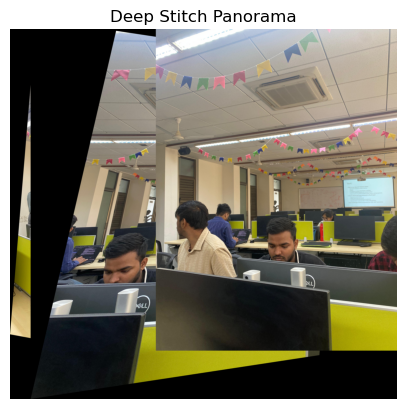

Lab Completed


In [1]:
# ------------------------------------------------
# Image Stitching + Deep Stitching
# ------------------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import os
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

# ------------------------------------------------
# 0. Configuration
# ------------------------------------------------

IMAGE_FOLDER = "images/panorama_set"
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

# Load pretrained CNN for deep features
deep_model = ResNet50(weights="imagenet", include_top=False, pooling="avg")


# ------------------------------------------------
# Load Images
# ------------------------------------------------

def load_images(folder: str) -> List[np.ndarray]:

    images = []

    for file in sorted(os.listdir(folder)):

        if Path(file).suffix.lower() in IMAGE_EXTENSIONS:

            img_path = os.path.join(folder, file)

            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)
                print("Loaded:", file, img.shape)

    return images


# ------------------------------------------------
# Show Images
# ------------------------------------------------

def show_images(images, titles=None):

    plt.figure(figsize=(15,6))

    for i,img in enumerate(images):

        plt.subplot(1,len(images),i+1)

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        if titles:
            plt.title(titles[i])

        plt.axis("off")

    plt.show()


# ------------------------------------------------
# ORB Feature Matching
# ------------------------------------------------

def detect_and_match_features(img1, img2):

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(2000)

    kp1, des1 = orb.detectAndCompute(gray1,None)
    kp2, des2 = orb.detectAndCompute(gray2,None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1,des2,k=2)

    good=[]

    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)

    return kp1,kp2,good


# ------------------------------------------------
# Deep Feature Extraction
# ------------------------------------------------

def extract_deep_feature(img):

    img = cv2.resize(img,(224,224))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    x = np.expand_dims(img,axis=0)

    x = preprocess_input(x)

    #feature = deep_model.predict(x,verbose=0)
    feature = deep_model(x, training=False).numpy()

    return feature.flatten()


# ------------------------------------------------
# Homography
# ------------------------------------------------

def compute_homography(kp1,kp2,good):

    if len(good) < 10:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)

    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H,_ = cv2.findHomography(src_pts,dst_pts,cv2.RANSAC,5.0)

    return H


# ------------------------------------------------
# Stitch Two Images
# ------------------------------------------------

def stitch_two_images(img1,img2,H):

    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]

    corners = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)

    warped_corners = cv2.perspectiveTransform(corners,H)

    all_corners = np.concatenate((np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2),warped_corners),axis=0)

    xmin,ymin = np.int32(all_corners.min(axis=0).ravel()-0.5)
    xmax,ymax = np.int32(all_corners.max(axis=0).ravel()+0.5)

    translation = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]])

    result = cv2.warpPerspective(img2,translation.dot(H),(xmax-xmin,ymax-ymin))

    result[-ymin:h1-ymin,-xmin:w1-xmin] = img1

    return result


# ------------------------------------------------
# Sequential Stitch
# ------------------------------------------------

def manual_stitch(images):

    panorama = images[0]

    for i in range(1,len(images)):

        kp1,kp2,good = detect_and_match_features(panorama,images[i])

        H = compute_homography(kp1,kp2,good)

        if H is None:
            print("Homography failed")
            continue

        panorama = stitch_two_images(panorama,images[i],H)

    return panorama


# ------------------------------------------------
# Deep Stitch
# ------------------------------------------------

def deep_stitch(images):

    panorama = images[0]

    for i in range(1,len(images)):

        print(f"\n🔹 Processing image {i}...")

        f1 = extract_deep_feature(panorama)
        f2 = extract_deep_feature(images[i])

        similarity = np.dot(f1,f2)/(np.linalg.norm(f1)*np.linalg.norm(f2))

        print("✅ Deep similarity:", similarity)

        kp1,kp2,good = detect_and_match_features(panorama,images[i])

        print("Matches found:", len(good))

        if len(good) < 10:
            print("❌ Not enough matches → skipping")
            continue

        H = compute_homography(kp1,kp2,good)

        if H is None:
            print("❌ Homography failed → skipping")
            continue

        print("✅ Stitching success")

        panorama = stitch_two_images(panorama,images[i],H)

    return panorama

# ------------------------------------------------
# MAIN
# ------------------------------------------------

images = load_images(IMAGE_FOLDER)
if len(images)<2:
    raise ValueError("Need at least 2 images")

show_images(images[:4])

# Manual
print("\nManual Stitching")
manual_pano = manual_stitch(images)

plt.imshow(cv2.cvtColor(manual_pano,cv2.COLOR_BGR2RGB))
plt.title("Manual Panorama")
plt.axis("off")
plt.show()


# OpenCV Stitcher
print("\nOpenCV Stitcher")

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

status,pano = stitcher.stitch(images)

if status == cv2.Stitcher_OK:

    plt.imshow(cv2.cvtColor(pano,cv2.COLOR_BGR2RGB))
    plt.title("OpenCV Panorama")
    plt.axis("off")
    plt.show()


# Deep Stitch
print("\nDeep Stitching")

deep_pano = deep_stitch(images)

plt.imshow(cv2.cvtColor(deep_pano,cv2.COLOR_BGR2RGB))
plt.title("Deep Stitch Panorama")
plt.axis("off")
plt.show()

print("Lab Completed")